In [1]:
# Cell 1: setup, load gap-fill trials, verify counts
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

DATA_RAW       = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
GAPFILL_DIR    = DATA_RAW / "step_responses_gapfill"
SESSION_LOG    = DATA_RAW / "session_log.csv"

# Constants — IDENTICAL to notebook 03
STEP_START_MS       = 500
SS_WINDOW_MS        = (4000, 5000)        # post-step SS window, relative to STEP_START
STEP_DOWN_START_MS  = 3000
SS_INIT_WINDOW_MS   = (2000, 3000)
SS_FINAL_WINDOW_MS  = (7000, 8000)
NOISE_THRESH_RPM    = 2.0
DIR_SIGN = {'F': 1, 'R': -1, 'N': 0}

UP_PATTERN   = re.compile(r"step_up_(fwd|rev)_(\d+)_run0?(\d+)\.csv$")
DOWN_PATTERN = re.compile(r"step_down_(fwd|rev)_(\d+)to(\d+)_run0?(\d+)\.csv$")

up_trials, down_trials, unmatched = {}, {}, []
for f in sorted(GAPFILL_DIR.glob("*.csv")):
    m = UP_PATTERN.search(f.name)
    if m:
        d, p, r = m.group(1), int(m.group(2)), int(m.group(3))
        up_trials[(d, p, r)] = pd.read_csv(f)
        continue
    m = DOWN_PATTERN.search(f.name)
    if m:
        d, s, t, r = m.group(1), int(m.group(2)), int(m.group(3)), int(m.group(4))
        down_trials[(d, s, t, r)] = pd.read_csv(f)
        continue
    unmatched.append(f.name)

print(f"Loaded {len(up_trials)} step-up trials, {len(down_trials)} step-down trials")
print(f"Total: {len(up_trials) + len(down_trials)} (expect 46)")
print(f"Unmatched: {unmatched}")
print()

print("Step-up runs per condition:")
for (d, p) in sorted({(d, p) for (d, p, _) in up_trials.keys()}):
    runs = sorted(r for (dd, pp, r) in up_trials.keys() if dd==d and pp==p)
    print(f"  {d} pwm={p:3d}: runs={runs}  (n={len(runs)})")

print("\nStep-down runs per condition:")
for (d, s, t) in sorted({(d, s, t) for (d, s, t, _) in down_trials.keys()}):
    runs = sorted(r for (dd, ss, tt, r) in down_trials.keys() if dd==d and ss==s and tt==t)
    print(f"  {d} {s}->{t:3d}: runs={runs}  (n={len(runs)})")

print("\n=== Session log ===")
print(pd.read_csv(SESSION_LOG).to_string(index=False))

Loaded 28 step-up trials, 18 step-down trials
Total: 46 (expect 46)
Unmatched: []

Step-up runs per condition:
  fwd pwm=180: runs=[1, 2, 3, 4, 5]  (n=5)
  fwd pwm=200: runs=[1, 2]  (n=2)
  fwd pwm=220: runs=[1, 2, 3, 4, 5]  (n=5)
  fwd pwm=240: runs=[1, 2]  (n=2)
  rev pwm=180: runs=[1, 2, 3, 4, 5]  (n=5)
  rev pwm=200: runs=[1, 2]  (n=2)
  rev pwm=220: runs=[1, 2, 3, 4, 5]  (n=5)
  rev pwm=240: runs=[1, 2]  (n=2)

Step-down runs per condition:
  fwd 240->100: runs=[1, 2, 3]  (n=3)
  fwd 240->180: runs=[1, 2, 3]  (n=3)
  fwd 240->220: runs=[1, 2, 3]  (n=3)
  rev 240->100: runs=[1, 2, 3]  (n=3)
  rev 240->180: runs=[1, 2, 3]  (n=3)
  rev 240->220: runs=[1, 2, 3]  (n=3)

=== Session log ===
 timestamp  T_celsius          notes
       NaN        NaN 40 deg celsius
       NaN       27.3     before run
       NaN       28.8      after run


In [3]:
# Cell 2: piggyback fits, compare to Phase 2.1 per-condition means.
# Fit functions are bit-identical copies from notebook 03.

def heuristic_fopdt(df):
    t = df["t_ms"].values
    r = df["rpm"].values.astype(float)
    lo, hi = SS_WINDOW_MS
    ss_mask = (t >= STEP_START_MS + lo) & (t <= STEP_START_MS + hi)
    if not ss_mask.any(): return None
    K_ss = r[ss_mask].mean()
    sign = 1 if K_ss >= 0 else -1
    r_abs, K_abs = sign*r, sign*K_ss
    post = t >= STEP_START_MS
    above = post & (r_abs > NOISE_THRESH_RPM)
    if not above.any(): return None
    Td_ms = t[above][0] - STEP_START_MS
    crossed = post & (r_abs >= 0.632 * K_abs)
    if not crossed.any(): return None
    tau_ms = (t[crossed][0] - STEP_START_MS) - Td_ms
    return {"K_ss": K_ss, "Td_ms": Td_ms, "tau_ms": tau_ms}

def fopdt_model(t, K, Td, tau):
    out = np.zeros_like(t, dtype=float)
    on = t >= (STEP_START_MS + Td)
    out[on] = K * (1 - np.exp(-(t[on] - STEP_START_MS - Td) / tau))
    return out

def fit_fopdt_curve(df):
    t = df["t_ms"].values.astype(float)
    r = df["rpm"].values.astype(float)
    h = heuristic_fopdt(df)
    if h is None: return {"fit_ok": False, "error": "heuristic failed"}
    K0, Td0, tau0 = h["K_ss"], h["Td_ms"], h["tau_ms"]
    K_max = abs(K0) * 2
    if K0 >= 0:
        lower, upper = [0, 0, 10], [K_max, 200, 1000]
    else:
        lower, upper = [-K_max, 0, 10], [0, 200, 1000]
    try:
        popt, _ = curve_fit(fopdt_model, t, r, p0=[K0, Td0, tau0],
                            bounds=(lower, upper), max_nfev=5000)
    except Exception as e:
        return {"fit_ok": False, "error": str(e)}
    K, Td, tau = popt
    res = r - fopdt_model(t, *popt)
    rise = (t >= STEP_START_MS) & (t <= STEP_START_MS + 1500)
    ss   = (t >= STEP_START_MS + 4000) & (t <= STEP_START_MS + 5000)
    return {"K_ss": K, "Td_ms": Td, "tau_ms": tau,
            "rms_rise": float(np.sqrt(np.mean(res[rise]**2))),
            "rms_ss":   float(np.sqrt(np.mean(res[ss]**2))),
            "rms_total":float(np.sqrt(np.mean(res**2))),
            "fit_ok": True}

# Fit the 8 piggyback trials
PIGGYBACK_CONDS = [("fwd", 200), ("fwd", 240), ("rev", 200), ("rev", 240)]
records = []
for (d, p) in PIGGYBACK_CONDS:
    for run in [1, 2]:
        f = fit_fopdt_curve(up_trials[(d, p, run)])
        rec = {"direction": d, "pwm": p, "run": run}
        for k in ["K_ss", "Td_ms", "tau_ms", "rms_rise", "rms_ss", "rms_total"]:
            rec[k] = f.get(k, np.nan)
        rec["fit_ok"] = f.get("fit_ok", False)
        records.append(rec)
pig = pd.DataFrame(records)
print("=== Piggyback per-trial fits (gap-fill session) ===")
print(pig.round(2).to_string(index=False))

# Phase 2.1 per-condition means for comparison
p21 = pd.read_csv(DATA_PROCESSED / "phase21_fopdt_curvefit_per_condition.csv")
print("\n=== Phase 2.1 per-condition (full table for reference) ===")
print(p21.round(2).to_string(index=False))

# Per-condition piggyback vs Phase 2.1
pig_agg = (pig.groupby(["direction", "pwm"])
           .agg(K_ss_pig=("K_ss", "mean"),
                Td_pig=("Td_ms", "mean"),
                tau_pig=("tau_ms", "mean"),
                n=("fit_ok", "sum")).reset_index())

cmp = pig_agg.merge(
    p21.rename(columns={"K_ss_mean":"K_ss_p21",
                        "Td_mean":"Td_p21",  "Td_std":"Td_p21_std",
                        "tau_mean":"tau_p21","tau_std":"tau_p21_std"}),
    on=["direction", "pwm"], how="left")

cmp["dK_ss"]         = cmp["K_ss_pig"] - cmp["K_ss_p21"]
cmp["dTd"]           = cmp["Td_pig"]   - cmp["Td_p21"]
cmp["dTd_in_sigma"]  = cmp["dTd"]      / cmp["Td_p21_std"]
cmp["dtau"]          = cmp["tau_pig"]  - cmp["tau_p21"]
cmp["dtau_in_sigma"] = cmp["dtau"]     / cmp["tau_p21_std"]

print("\n=== Piggyback (n=2) vs Phase 2.1 (n=3): per-condition deltas ===")
print(cmp[["direction","pwm",
           "K_ss_pig","K_ss_p21","dK_ss",
           "Td_pig","Td_p21","dTd","dTd_in_sigma",
           "tau_pig","tau_p21","dtau","dtau_in_sigma"]]
      .round(2).to_string(index=False))

print("\nRule of thumb for |delta| / Phase-2.1-sigma:")
print("  < 1   : well within session noise — proceed")
print("  1–2   : borderline — flag and proceed with caution")
print("  > 2   : real drift — pause, investigate before trusting new fits")

=== Piggyback per-trial fits (gap-fill session) ===
direction  pwm  run    K_ss  Td_ms  tau_ms  rms_rise  rms_ss  rms_total  fit_ok
      fwd  200    1  116.27   0.00  131.42      4.23    3.91       3.48    True
      fwd  200    2  117.34   5.82  117.48      3.72    4.43       3.91    True
      fwd  240    1  205.55  16.39  217.19      6.88    7.25       6.71    True
      fwd  240    2  211.95  11.57  136.59      5.98    6.41       5.91    True
      rev  200    1 -125.36   6.99   79.06      3.72    4.07       3.85    True
      rev  200    2 -131.01   3.81   88.75      4.02    4.17       3.81    True
      rev  240    1 -218.73  15.27  112.11      6.12    6.32       5.90    True
      rev  240    2 -217.75  14.10  115.96      6.00    6.46       5.74    True

=== Phase 2.1 per-condition (full table for reference) ===
direction  pwm  K_ss_mean  Td_mean  Td_std  tau_mean  tau_std  rms_rise_mean  rms_ss_mean
      fwd  160      52.08     0.00    0.00    200.09    22.02           2.61  

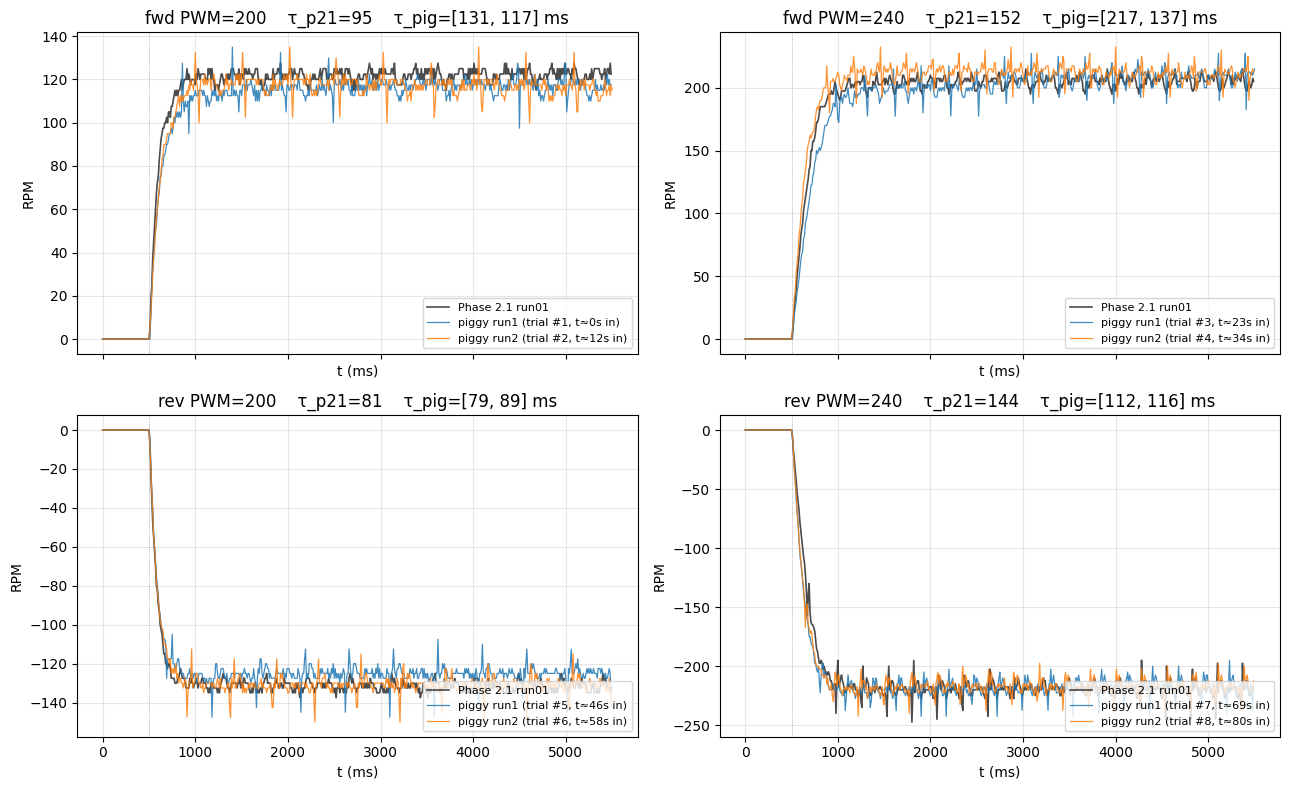

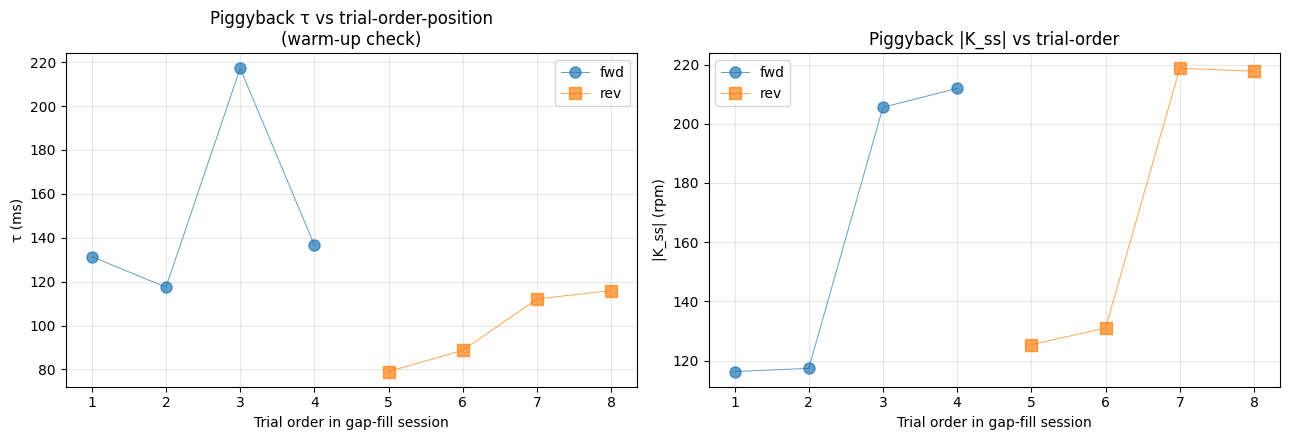


=== Piggyback ordered by trial position ===
 order direction  pwm  run  tau_ms    K_ss  t_start_s
     1       fwd  200    1  131.42  116.27        0.0
     2       fwd  200    2  117.48  117.34       11.5
     3       fwd  240    1  217.19  205.55       23.0
     4       fwd  240    2  136.59  211.95       34.5
     5       rev  200    1   79.06 -125.36       46.0
     6       rev  200    2   88.75 -131.01       57.5
     7       rev  240    1  112.11 -218.73       69.0
     8       rev  240    2  115.96 -217.75       80.5


In [4]:
# Cell 3: visualize piggyback vs Phase 2.1, check for warm-up trend

PHASE21_DIR = DATA_RAW / "step_responses"

# Trial-order position in the gap-fill firmware (from step_response_v2.cpp)
PIGGYBACK_ORDER = {
    ("fwd", 200, 1): 1, ("fwd", 200, 2): 2,
    ("fwd", 240, 1): 3, ("fwd", 240, 2): 4,
    ("rev", 200, 1): 5, ("rev", 200, 2): 6,
    ("rev", 240, 1): 7, ("rev", 240, 2): 8,
}
# Each trial = ~8.5 s + 3 s rest. Cumulative time at trial-start:
TIME_AT_TRIAL_START_S = {n: (n - 1) * 11.5 for n in range(1, 9)}

# --- Plot 1: overlay piggyback (2 runs) vs Phase 2.1 (run01) for each condition ---
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
PIG_CONDS_GRID = [("fwd", 200), ("fwd", 240), ("rev", 200), ("rev", 240)]

for ax, (d, p) in zip(axes.flat, PIG_CONDS_GRID):
    # Phase 2.1 reference: load run01
    p21_path = PHASE21_DIR / f"step_up_{d}_{p}_run01.csv"
    if p21_path.exists():
        p21_df = pd.read_csv(p21_path)
        ax.plot(p21_df["t_ms"], p21_df["rpm"],
                color="black", lw=1.2, alpha=0.7, label="Phase 2.1 run01")

    # Gap-fill piggyback runs
    for run, color in [(1, "C0"), (2, "C1")]:
        df = up_trials[(d, p, run)]
        order = PIGGYBACK_ORDER[(d, p, run)]
        t_start = TIME_AT_TRIAL_START_S[order]
        ax.plot(df["t_ms"], df["rpm"], color=color, lw=0.9, alpha=0.85,
                label=f"piggy run{run} (trial #{order}, t≈{t_start:.0f}s in)")

    pig_taus = pig[(pig.direction==d) & (pig.pwm==p)]["tau_ms"].values
    p21_tau = p21.query(f"direction=='{d}' and pwm=={p}")["tau_mean"].iloc[0]
    ax.set_title(f"{d} PWM={p}    τ_p21={p21_tau:.0f}    "
                 f"τ_pig=[{pig_taus[0]:.0f}, {pig_taus[1]:.0f}] ms")
    ax.axvline(STEP_START_MS, color="gray", ls=":", lw=0.5)
    ax.set_xlabel("t (ms)")
    ax.set_ylabel("RPM")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(Path("../figures/14_phase2gapfill_piggyback_overlay.png"), dpi=140)
plt.show()

# --- Plot 2: τ vs trial-order-position-in-session (warm-up trend) ---
trial_order_taus = []
for (d, p, run), order in PIGGYBACK_ORDER.items():
    row = pig[(pig.direction==d) & (pig.pwm==p) & (pig.run==run)].iloc[0]
    trial_order_taus.append({
        "order": order, "direction": d, "pwm": p, "run": run,
        "tau_ms": row["tau_ms"], "K_ss": row["K_ss"],
        "t_start_s": TIME_AT_TRIAL_START_S[order],
    })
tot = pd.DataFrame(trial_order_taus).sort_values("order")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for d, marker in [("fwd", "o"), ("rev", "s")]:
    sub = tot[tot.direction == d]
    ax1.plot(sub["order"], sub["tau_ms"], marker=marker, ms=8,
             label=d, lw=0.7, ls="-", alpha=0.7)
ax1.set_xlabel("Trial order in gap-fill session")
ax1.set_ylabel("τ (ms)")
ax1.set_title("Piggyback τ vs trial-order-position\n(warm-up check)")
ax1.set_xticks(range(1, 9))
ax1.legend()
ax1.grid(True, alpha=0.3)

for d, marker in [("fwd", "o"), ("rev", "s")]:
    sub = tot[tot.direction == d]
    ax2.plot(sub["order"], sub["K_ss"].abs(), marker=marker, ms=8,
             label=d, lw=0.7, ls="-", alpha=0.7)
ax2.set_xlabel("Trial order in gap-fill session")
ax2.set_ylabel("|K_ss| (rpm)")
ax2.set_title("Piggyback |K_ss| vs trial-order")
ax2.set_xticks(range(1, 9))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path("../figures/15_phase2gapfill_warmup_trend.png"), dpi=140)
plt.show()

print("\n=== Piggyback ordered by trial position ===")
print(tot[["order","direction","pwm","run","tau_ms","K_ss","t_start_s"]]
      .round(2).to_string(index=False))

In [5]:
# Cell 4: Phase 2.1 trial-level outlier audit
# Quantify what "outlier" rate Phase 2.1 actually had, for context on trial 3.

p21_pt = pd.read_csv(DATA_PROCESSED / "phase21_fopdt_curvefit_per_trial.csv")
print(f"Phase 2.1 per-trial: shape={p21_pt.shape}")
print(p21_pt[['direction','pwm','run','K_ss','Td_ms','tau_ms','rms_rise']].round(2).to_string(index=False))

# Per-condition stats from per-trial table
cond_stats = (p21_pt.groupby(['direction','pwm'])
              .agg(K_ss_mean=('K_ss','mean'), K_ss_std=('K_ss','std'),
                   Td_mean=('Td_ms','mean'),  Td_std=('Td_ms','std'),
                   tau_mean=('tau_ms','mean'),tau_std=('tau_ms','std'))
              .reset_index())

# Deviations of each trial from its condition mean
audit = p21_pt.merge(cond_stats, on=['direction','pwm'])
audit['dtau']         = audit['tau_ms'] - audit['tau_mean']
audit['dtau_pct']     = 100 * audit['dtau'] / audit['tau_mean']
audit['dtau_in_sigma']= audit['dtau'] / audit['tau_std']

print("\n=== Phase 2.1 per-trial τ deviations from per-condition mean ===")
print(audit[['direction','pwm','run','tau_ms','tau_mean','dtau','dtau_pct','dtau_in_sigma']]
      .round(2).sort_values('dtau_pct', key=lambda x: x.abs(), ascending=False)
      .to_string(index=False))

# Define "outlier" two ways
outliers_pct = audit[audit['dtau_pct'].abs() > 30]
outliers_sigma = audit[audit['dtau_in_sigma'].abs() > 2]

print(f"\nPhase 2.1 trials with |Δτ| > 30%: {len(outliers_pct)} of {len(audit)}")
print(f"Phase 2.1 trials with |Δτ| > 2σ:  {len(outliers_sigma)} of {len(audit)}")

# Gap-fill piggyback equivalent
pig_audit = pig.merge(
    p21.rename(columns={'tau_mean':'tau_p21','tau_std':'tau_p21_std'})[
        ['direction','pwm','tau_p21','tau_p21_std']],
    on=['direction','pwm'])
pig_audit['dtau_pct'] = 100 * (pig_audit['tau_ms'] - pig_audit['tau_p21']) / pig_audit['tau_p21']
pig_audit['dtau_in_sigma'] = (pig_audit['tau_ms'] - pig_audit['tau_p21']) / pig_audit['tau_p21_std']

print(f"\n=== Gap-fill piggyback Δτ vs Phase 2.1 (for comparison) ===")
print(pig_audit[['direction','pwm','run','tau_ms','tau_p21','dtau_pct','dtau_in_sigma']]
      .round(2).sort_values('dtau_pct', key=lambda x: x.abs(), ascending=False)
      .to_string(index=False))

print(f"\nGap-fill piggyback trials with |Δτ| > 30%: "
      f"{len(pig_audit[pig_audit['dtau_pct'].abs() > 30])} of {len(pig_audit)}")

Phase 2.1 per-trial: shape=(18, 10)
direction  pwm  run    K_ss  Td_ms  tau_ms  rms_rise
      fwd  160    1   48.96   0.00  225.04      3.17
      fwd  160    2   53.00   0.00  183.34      2.10
      fwd  160    3   54.28   0.00  191.90      2.58
      fwd  200    1  121.99   4.00   99.69      2.57
      fwd  200    2  124.41   5.71   95.20      2.36
      fwd  200    3  124.18   5.05   90.40      2.50
      fwd  240    1  205.09  17.76  151.83      4.54
      fwd  240    2  210.79  17.10  149.76      4.75
      fwd  240    3  213.34  16.31  155.18      4.78
      rev  160    1  -71.14   0.00  178.18      4.52
      rev  160    2  -67.87   0.00  201.78      2.88
      rev  160    3  -69.65   0.00  195.00      4.69
      rev  200    1 -131.47   5.33   81.22      2.39
      rev  200    2 -131.17   5.88   80.31      2.35
      rev  200    3 -131.41   5.68   82.19      3.24
      rev  240    1 -219.90  22.76  142.82      7.30
      rev  240    2 -223.36  23.71  147.25      7.22
      rev 

=== New accel per-trial fits (20 trials) ===
direction  pwm  run    K_ss  Td_ms  tau_ms  rms_rise  rms_ss  rms_total  fit_ok
      fwd  180    1   86.62   8.56   93.15      3.98    4.15       3.87    True
      fwd  180    2   90.48   0.00  107.27      3.57    3.84       3.63    True
      fwd  180    3   90.86   0.00  106.94      3.79    3.49       3.55    True
      fwd  180    4   89.36   3.12   98.27      3.51    3.79       3.46    True
      fwd  180    5   90.43   0.00  108.99      3.63    3.31       3.08    True
      fwd  220    1  175.06   4.85  106.72      5.25    5.59       5.28    True
      fwd  220    2  175.62   6.97  106.72      4.88    4.92       4.93    True
      fwd  220    3  175.80   7.51  107.35      4.99    5.09       4.79    True
      fwd  220    4  175.06   7.16  110.28      4.83    5.24       4.84    True
      fwd  220    5  175.33   5.66  110.96      4.87    5.09       4.77    True
      rev  180    1  -95.23   2.14   91.70      3.20    3.60       3.18    

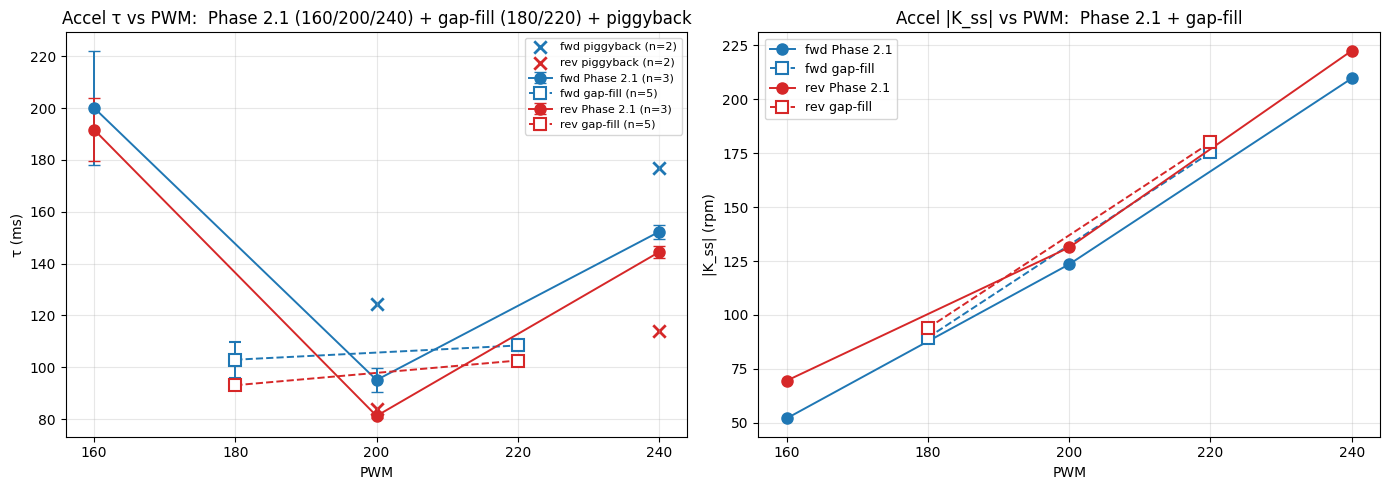

In [6]:
# Cell 5: Fit new accel conditions (PWM 180, 220), save tables, plot τ landscape

# New accel conditions: 4 conditions x 5 runs each = 20 trials
NEW_ACCEL_CONDS = [("fwd", 180), ("fwd", 220), ("rev", 180), ("rev", 220)]
NEW_RUNS = [1, 2, 3, 4, 5]

records = []
for (d, p) in NEW_ACCEL_CONDS:
    for run in NEW_RUNS:
        f = fit_fopdt_curve(up_trials[(d, p, run)])
        rec = {"direction": d, "pwm": p, "run": run}
        for k in ["K_ss", "Td_ms", "tau_ms", "rms_rise", "rms_ss", "rms_total"]:
            rec[k] = f.get(k, np.nan)
        rec["fit_ok"] = f.get("fit_ok", False)
        records.append(rec)

new_accel = pd.DataFrame(records).sort_values(["direction","pwm","run"]).reset_index(drop=True)
print("=== New accel per-trial fits (20 trials) ===")
print(new_accel.round(2).to_string(index=False))
print(f"\nFit success: {new_accel['fit_ok'].sum()} / {len(new_accel)}")

# Per-condition aggregate (n=5)
new_accel_agg = (new_accel.groupby(["direction","pwm"])
                 .agg(K_ss_mean=("K_ss","mean"),  K_ss_std=("K_ss","std"),
                      Td_mean  =("Td_ms","mean"), Td_std  =("Td_ms","std"),
                      tau_mean =("tau_ms","mean"),tau_std =("tau_ms","std"),
                      rms_rise_mean=("rms_rise","mean"),
                      rms_ss_mean  =("rms_ss","mean"),
                      n=("fit_ok","sum"))
                 .reset_index())
print("\n=== New accel per-condition (n=5) ===")
print(new_accel_agg.round(2).to_string(index=False))

# Save
new_accel.to_csv(DATA_PROCESSED / "phase2gapfill_fopdt_accel_per_trial.csv", index=False)
new_accel_agg.to_csv(DATA_PROCESSED / "phase2gapfill_fopdt_accel_per_condition.csv", index=False)
print(f"\nSaved: phase2gapfill_fopdt_accel_per_trial.csv (20 rows)")
print(f"       phase2gapfill_fopdt_accel_per_condition.csv (4 rows)")

# Plot: τ vs PWM, Phase 2.1 + gap-fill overlay
fig, (ax_tau, ax_K) = plt.subplots(1, 2, figsize=(14, 5))

for direction, color in [("fwd", "C0"), ("rev", "C3")]:
    # Phase 2.1: PWM 160, 200, 240
    p21_sub = p21[p21.direction == direction].sort_values("pwm")
    ax_tau.errorbar(p21_sub["pwm"], p21_sub["tau_mean"], yerr=p21_sub["tau_std"],
                    marker="o", ms=8, lw=1.4, color=color, capsize=4,
                    label=f"{direction} Phase 2.1 (n=3)")

    # Gap-fill new accel: PWM 180, 220
    gf_sub = new_accel_agg[new_accel_agg.direction == direction].sort_values("pwm")
    ax_tau.errorbar(gf_sub["pwm"], gf_sub["tau_mean"], yerr=gf_sub["tau_std"],
                    marker="s", ms=8, lw=1.4, color=color, capsize=4,
                    linestyle="--", mfc="white", mew=1.5,
                    label=f"{direction} gap-fill (n=5)")

    # Gap-fill piggyback: PWM 200, 240 (overlay for context)
    pig_sub = pig_agg[pig_agg.direction == direction].sort_values("pwm")
    ax_tau.scatter(pig_sub["pwm"], pig_sub["tau_pig"],
                   marker="x", s=80, color=color, lw=2,
                   label=f"{direction} piggyback (n=2)")

for direction, color in [("fwd", "C0"), ("rev", "C3")]:
    p21_sub = p21[p21.direction == direction].sort_values("pwm")
    ax_K.plot(p21_sub["pwm"], p21_sub["K_ss_mean"].abs(),
              marker="o", ms=8, lw=1.4, color=color, label=f"{direction} Phase 2.1")
    gf_sub = new_accel_agg[new_accel_agg.direction == direction].sort_values("pwm")
    ax_K.plot(gf_sub["pwm"], gf_sub["K_ss_mean"].abs(),
              marker="s", ms=8, lw=1.4, color=color, linestyle="--",
              mfc="white", mew=1.5, label=f"{direction} gap-fill")

ax_tau.set_xlabel("PWM"); ax_tau.set_ylabel("τ (ms)")
ax_tau.set_title("Accel τ vs PWM:  Phase 2.1 (160/200/240) + gap-fill (180/220) + piggyback")
ax_tau.set_xticks([160, 180, 200, 220, 240])
ax_tau.legend(fontsize=8); ax_tau.grid(True, alpha=0.3)

ax_K.set_xlabel("PWM"); ax_K.set_ylabel("|K_ss| (rpm)")
ax_K.set_title("Accel |K_ss| vs PWM:  Phase 2.1 + gap-fill")
ax_K.set_xticks([160, 180, 200, 220, 240])
ax_K.legend(fontsize=9); ax_K.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path("../figures/16_phase2gapfill_accel_tau_vs_pwm.png"), dpi=140)
plt.show()

=== New decel per-trial fits (18 trials) ===
direction  start_pwm  target_pwm  run  y_init  y_final  Td_ms  tau_ms  rms_decel  rms_total  fit_ok
      fwd        240         100    1  220.65     2.17  26.91  365.51       4.89       4.71    True
      fwd        240         100    2  221.00    -0.02  24.60  368.09       4.61       3.50    True
      fwd        240         100    3  219.78     1.11  25.02  365.09       4.72       4.02    True
      fwd        240         180    1  220.04    95.08   0.00  353.15       4.21       4.43    True
      fwd        240         180    2  218.92    93.78   0.00  356.26       4.21       4.41    True
      fwd        240         180    3  220.64    93.67   0.99  360.24       4.42       4.59    True
      fwd        240         220    1  217.14   174.85  24.72  106.71       5.50       5.60    True
      fwd        240         220    2  218.17   174.75   0.00  138.99       5.33       5.65    True
      fwd        240         220    3  222.92   178.21 

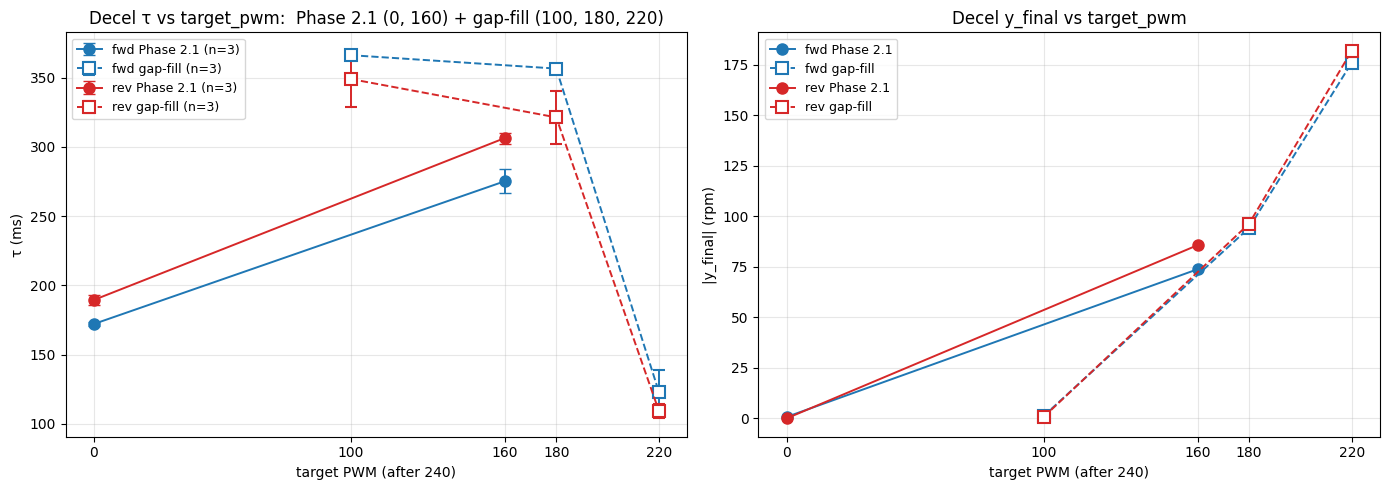

In [7]:
# Cell 6: Section C — fit new decel conditions, save tables, plot τ landscape

# Step-down fit functions — bit-identical copy from notebook 03 (t>=2000 fit window)
def fopdt_step_down_model(t, y_init, y_final, Td, tau):
    out = np.full_like(t, y_init, dtype=float)
    on = t >= (STEP_DOWN_START_MS + Td)
    out[on] = y_final + (y_init - y_final) * np.exp(-(t[on] - STEP_DOWN_START_MS - Td) / tau)
    return out

def fit_fopdt_step_down(df, fit_start_ms=2000):
    t_full = df["t_ms"].values.astype(float)
    r_full = df["rpm"].values.astype(float)
    fit_mask = t_full >= fit_start_ms
    t = t_full[fit_mask]
    r = r_full[fit_mask]

    init_mask  = (t >= SS_INIT_WINDOW_MS[0])  & (t <= SS_INIT_WINDOW_MS[1])
    final_mask = (t >= SS_FINAL_WINDOW_MS[0]) & (t <= SS_FINAL_WINDOW_MS[1])
    if not init_mask.any() or not final_mask.any():
        return {"fit_ok": False, "error": "ss windows empty"}

    y_init0  = r[init_mask].mean()
    y_final0 = r[final_mask].mean()
    sign = 1 if y_init0 >= 0 else -1

    if sign > 0:
        lower, upper = [0, -10, 0, 10], [400, 400, 200, 1000]
    else:
        lower, upper = [-400, -400, 0, 10], [10, 0, 200, 1000]

    try:
        popt, _ = curve_fit(fopdt_step_down_model, t, r,
                            p0=[y_init0, y_final0, 10, 100],
                            bounds=(lower, upper), max_nfev=5000)
    except Exception as e:
        return {"fit_ok": False, "error": str(e)}

    y_init, y_final, Td, tau = popt
    res = r - fopdt_step_down_model(t, *popt)
    decel_mask = (t >= STEP_DOWN_START_MS) & (t <= STEP_DOWN_START_MS + 1500)

    return {"y_init": y_init, "y_final": y_final,
            "Td_ms": Td, "tau_ms": tau,
            "rms_decel": float(np.sqrt(np.mean(res[decel_mask]**2))),
            "rms_total": float(np.sqrt(np.mean(res**2))),
            "fit_ok": True}

# New decel conditions: 6 conditions x 3 runs each = 18 trials
NEW_DECEL_CONDS = [("fwd", 240, 100), ("fwd", 240, 180), ("fwd", 240, 220),
                   ("rev", 240, 100), ("rev", 240, 180), ("rev", 240, 220)]
NEW_DECEL_RUNS = [1, 2, 3]

records = []
for (d, s, t) in NEW_DECEL_CONDS:
    for run in NEW_DECEL_RUNS:
        f = fit_fopdt_step_down(down_trials[(d, s, t, run)])
        rec = {"direction": d, "start_pwm": s, "target_pwm": t, "run": run}
        for k in ["y_init", "y_final", "Td_ms", "tau_ms", "rms_decel", "rms_total"]:
            rec[k] = f.get(k, np.nan)
        rec["fit_ok"] = f.get("fit_ok", False)
        records.append(rec)

new_decel = pd.DataFrame(records).sort_values(
    ["direction","start_pwm","target_pwm","run"]).reset_index(drop=True)
print("=== New decel per-trial fits (18 trials) ===")
print(new_decel.round(2).to_string(index=False))
print(f"\nFit success: {new_decel['fit_ok'].sum()} / {len(new_decel)}")

# Per-condition aggregate (n=3)
new_decel_agg = (new_decel.groupby(["direction","start_pwm","target_pwm"])
                 .agg(y_init_mean =("y_init", "mean"),  y_init_std =("y_init", "std"),
                      y_final_mean=("y_final","mean"),  y_final_std=("y_final","std"),
                      Td_mean     =("Td_ms",  "mean"),  Td_std     =("Td_ms",  "std"),
                      tau_mean    =("tau_ms", "mean"),  tau_std    =("tau_ms", "std"),
                      rms_decel_mean=("rms_decel", "mean"),
                      n=("fit_ok","sum"))
                 .reset_index())
print("\n=== New decel per-condition (n=3) ===")
print(new_decel_agg.round(2).to_string(index=False))

# Save
new_decel.to_csv(DATA_PROCESSED / "phase2gapfill_stepdown_per_trial.csv", index=False)
new_decel_agg.to_csv(DATA_PROCESSED / "phase2gapfill_stepdown_per_condition.csv", index=False)
print(f"\nSaved: phase2gapfill_stepdown_per_trial.csv (18 rows)")
print(f"       phase2gapfill_stepdown_per_condition.csv (6 rows)")

# Plot: τ vs target_pwm, Phase 2.1 + gap-fill overlay
p21_decel = pd.read_csv(DATA_PROCESSED / "phase21_stepdown_curvefit_per_condition.csv")

fig, (ax_tau, ax_y) = plt.subplots(1, 2, figsize=(14, 5))

for direction, color in [("fwd", "C0"), ("rev", "C3")]:
    p21_sub = p21_decel[p21_decel.direction == direction].sort_values("target_pwm")
    ax_tau.errorbar(p21_sub["target_pwm"], p21_sub["tau_mean"], yerr=p21_sub["tau_std"],
                    marker="o", ms=8, lw=1.4, color=color, capsize=4,
                    label=f"{direction} Phase 2.1 (n=3)")

    gf_sub = new_decel_agg[new_decel_agg.direction == direction].sort_values("target_pwm")
    ax_tau.errorbar(gf_sub["target_pwm"], gf_sub["tau_mean"], yerr=gf_sub["tau_std"],
                    marker="s", ms=8, lw=1.4, color=color, capsize=4,
                    linestyle="--", mfc="white", mew=1.5,
                    label=f"{direction} gap-fill (n=3)")

for direction, color in [("fwd", "C0"), ("rev", "C3")]:
    p21_sub = p21_decel[p21_decel.direction == direction].sort_values("target_pwm")
    ax_y.plot(p21_sub["target_pwm"], p21_sub["y_final_mean"].abs(),
              marker="o", ms=8, lw=1.4, color=color, label=f"{direction} Phase 2.1")
    gf_sub = new_decel_agg[new_decel_agg.direction == direction].sort_values("target_pwm")
    ax_y.plot(gf_sub["target_pwm"], gf_sub["y_final_mean"].abs(),
              marker="s", ms=8, lw=1.4, color=color, linestyle="--",
              mfc="white", mew=1.5, label=f"{direction} gap-fill")

ax_tau.set_xlabel("target PWM (after 240)")
ax_tau.set_ylabel("τ (ms)")
ax_tau.set_title("Decel τ vs target_pwm:  Phase 2.1 (0, 160) + gap-fill (100, 180, 220)")
ax_tau.set_xticks([0, 100, 160, 180, 220])
ax_tau.legend(fontsize=9); ax_tau.grid(True, alpha=0.3)

ax_y.set_xlabel("target PWM (after 240)")
ax_y.set_ylabel("|y_final| (rpm)")
ax_y.set_title("Decel y_final vs target_pwm")
ax_y.set_xticks([0, 100, 160, 180, 220])
ax_y.legend(fontsize=9); ax_y.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path("../figures/17_phase2gapfill_decel_tau_vs_target.png"), dpi=140)
plt.show()

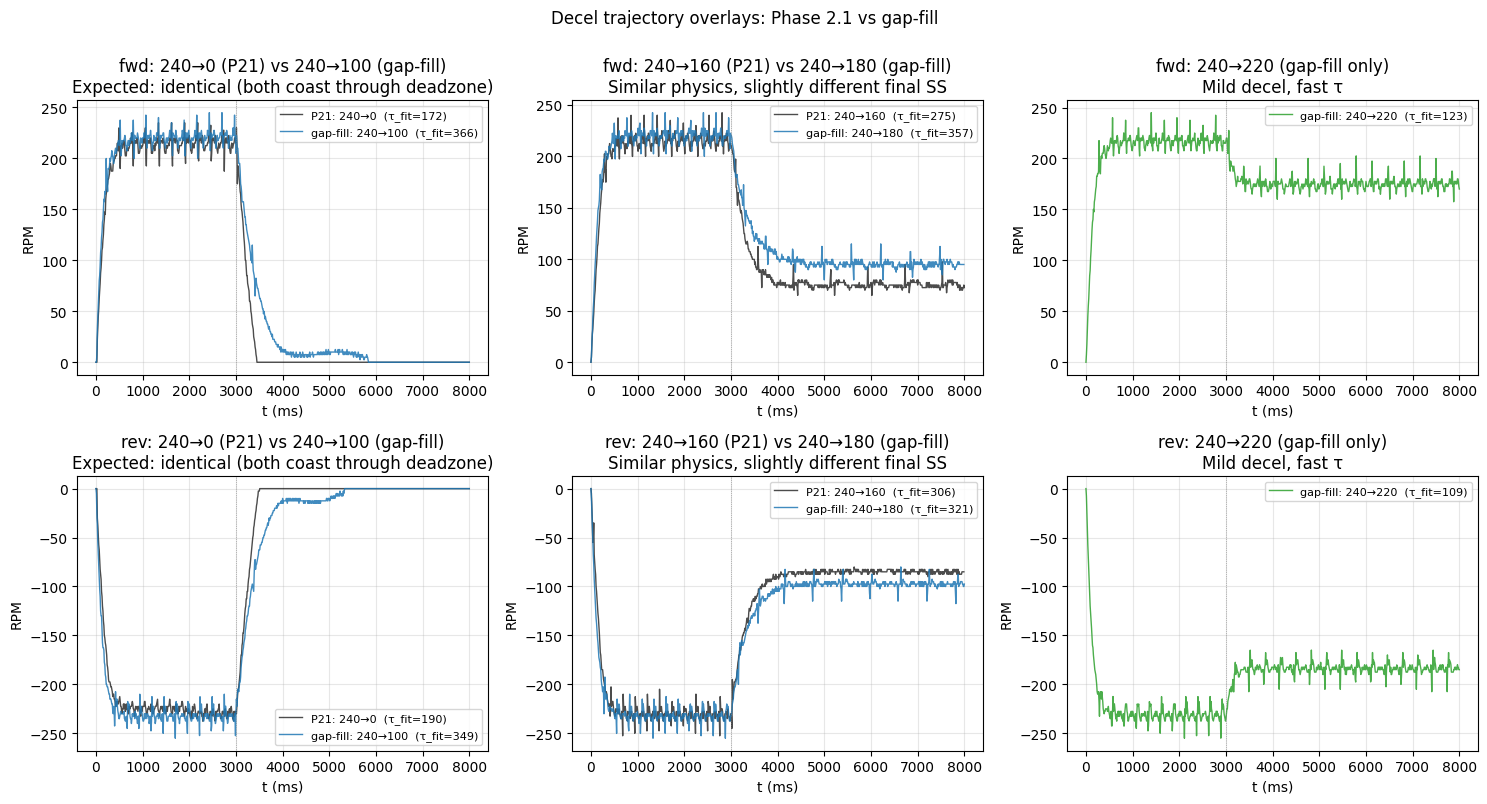

In [8]:
# Cell 7: trajectory overlay — Phase 2.1 vs gap-fill decel at nearby targets
P21_STEP_DIR = DATA_RAW / "step_responses"

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, d in enumerate(["fwd", "rev"]):
    # Column 1: Phase 2.1 240→0 vs gap-fill 240→100 (both should coast to ~0)
    ax = axes[row, 0]
    p21_path = P21_STEP_DIR / f"step_down_{d}_240to0_run01.csv"
    if p21_path.exists():
        df_p21 = pd.read_csv(p21_path)
        ax.plot(df_p21["t_ms"], df_p21["rpm"], "k-", lw=1.0, alpha=0.7,
                label="P21: 240→0  (τ_fit=" +
                      f"{p21_decel.query(f'direction==@d and target_pwm==0').tau_mean.iloc[0]:.0f})")
    df_gf = down_trials[(d, 240, 100, 1)]
    ax.plot(df_gf["t_ms"], df_gf["rpm"], "C0-", lw=1.0, alpha=0.85,
            label="gap-fill: 240→100  (τ_fit=" +
                  f"{new_decel_agg.query(f'direction==@d and target_pwm==100').tau_mean.iloc[0]:.0f})")
    ax.axvline(STEP_DOWN_START_MS, color="gray", ls=":", lw=0.5)
    ax.set_title(f"{d}: 240→0 (P21) vs 240→100 (gap-fill)\nExpected: identical (both coast through deadzone)")
    ax.set_xlabel("t (ms)"); ax.set_ylabel("RPM")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Column 2: Phase 2.1 240→160 vs gap-fill 240→180 (both decel to mid-range non-zero)
    ax = axes[row, 1]
    p21_path = P21_STEP_DIR / f"step_down_{d}_240to160_run01.csv"
    if p21_path.exists():
        df_p21 = pd.read_csv(p21_path)
        ax.plot(df_p21["t_ms"], df_p21["rpm"], "k-", lw=1.0, alpha=0.7,
                label="P21: 240→160  (τ_fit=" +
                      f"{p21_decel.query(f'direction==@d and target_pwm==160').tau_mean.iloc[0]:.0f})")
    df_gf = down_trials[(d, 240, 180, 1)]
    ax.plot(df_gf["t_ms"], df_gf["rpm"], "C0-", lw=1.0, alpha=0.85,
            label="gap-fill: 240→180  (τ_fit=" +
                  f"{new_decel_agg.query(f'direction==@d and target_pwm==180').tau_mean.iloc[0]:.0f})")
    ax.axvline(STEP_DOWN_START_MS, color="gray", ls=":", lw=0.5)
    ax.set_title(f"{d}: 240→160 (P21) vs 240→180 (gap-fill)\nSimilar physics, slightly different final SS")
    ax.set_xlabel("t (ms)"); ax.set_ylabel("RPM")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Column 3: gap-fill 240→220 (fast decel regime, no P21 reference)
    ax = axes[row, 2]
    df_gf = down_trials[(d, 240, 220, 1)]
    ax.plot(df_gf["t_ms"], df_gf["rpm"], "C2-", lw=1.0, alpha=0.85,
            label="gap-fill: 240→220  (τ_fit=" +
                  f"{new_decel_agg.query(f'direction==@d and target_pwm==220').tau_mean.iloc[0]:.0f})")
    ax.axvline(STEP_DOWN_START_MS, color="gray", ls=":", lw=0.5)
    ax.set_title(f"{d}: 240→220 (gap-fill only)\nMild decel, fast τ")
    ax.set_xlabel("t (ms)"); ax.set_ylabel("RPM")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Decel trajectory overlays: Phase 2.1 vs gap-fill", y=1.00)
plt.tight_layout()
plt.savefig(Path("../figures/18_phase2gapfill_decel_overlays.png"), dpi=140)
plt.show()

In [9]:
# Cell 8: Section E — LOOCV on new gap-fill conditions (accel n=5, decel n=3)

# --- Simulator (override_params path; copy of notebook 04 cell 6b logic) ---
def simulate_model_C(pwm_cmd, dt_ms=10, return_meta=False, override_params=None):
    """Single-transition simulator. override_params required for this cell's LOOCV use."""
    assert override_params is not None, "Cell 8 always uses override_params for LOOCV."
    pwm_cmd = np.asarray(pwm_cmd, dtype=float)
    n = len(pwm_cmd)
    transitions = np.where(np.abs(np.diff(np.abs(pwm_cmd))) > 0.5)[0]
    if len(transitions) == 0:
        return (np.zeros(n), {'regime': 'flat'}) if return_meta else np.zeros(n)
    if len(transitions) > 1:
        raise NotImplementedError(f"single-transition only; got {len(transitions)}")
    t_step = int(transitions[0] + 1)
    pwm_before, pwm_after = pwm_cmd[t_step - 1], pwm_cmd[t_step]
    abs_before, abs_after = int(round(abs(pwm_before))), int(round(abs(pwm_after)))
    if abs_after > abs_before:
        regime, direction = "accel", ("fwd" if pwm_after > 0 else "rev")
        p = {k: float(override_params[k]) for k in ('K_ss', 'Td', 'tau')}
        y_init, y_final = 0.0, p['K_ss']
    else:
        regime, direction = "decel", ("fwd" if pwm_before > 0 else "rev")
        p = {k: float(override_params[k]) for k in ('y_init', 'y_final', 'Td', 'tau')}
        y_init, y_final = p['y_init'], p['y_final']
    Td, tau = p['Td'], p['tau']
    rpm = np.empty(n)
    rpm[:t_step] = 0.0 if regime == "accel" else y_init
    for k in range(t_step, n):
        elapsed_ms = (k - t_step) * dt_ms - Td
        rpm[k] = (y_init if regime == "decel" else 0.0) if elapsed_ms < 0 else \
                 y_final + (y_init - y_final) * np.exp(-elapsed_ms / tau)
    meta = dict(regime=regime, direction=direction, pwm_before=abs_before, pwm_after=abs_after,
                K_ss=y_final, y_init=y_init, Td=Td, tau=tau, t_step=t_step)
    return (rpm, meta) if return_meta else rpm

def signed_pwm_from_trial(df):
    return df['pwm_cmd'].values * df['dir'].map(DIR_SIGN).values

def _rmse(a, b, mask):
    return float(np.sqrt(np.mean((a[mask] - b[mask])**2)))

# --- LOOCV: new accel (20 trials, n_others = 4 per trial) ---
accel_results = []
for _, row in new_accel.iterrows():
    if not row['fit_ok']: continue
    d, p_pwm, run = row['direction'], int(row['pwm']), int(row['run'])
    others = new_accel[(new_accel.direction == d) & (new_accel.pwm == p_pwm) &
                       (new_accel.run != run) & new_accel.fit_ok]
    assert len(others) == 4, f"Expected 4 others at {d} pwm={p_pwm} run={run}, got {len(others)}"
    override = {'K_ss': float(others.K_ss.mean()),
                'Td':   float(others.Td_ms.mean()),
                'tau':  float(others.tau_ms.mean())}
    trial = up_trials[(d, p_pwm, run)]
    pwm_sig = signed_pwm_from_trial(trial)
    rpm_meas = trial['rpm'].values
    rpm_pred, meta = simulate_model_C(pwm_sig, dt_ms=10, return_meta=True,
                                       override_params=override)
    t = trial['t_ms'].values
    t_rise_end = STEP_START_MS + 5 * meta['tau']
    mask_rise = (t >= STEP_START_MS) & (t < t_rise_end)
    mask_ss   = t >= t_rise_end
    accel_results.append({
        'direction': d, 'pwm': p_pwm, 'run': run,
        'K_ss_loocv': override['K_ss'], 'Td_loocv': override['Td'], 'tau_loocv': override['tau'],
        'K_ss_self':  float(row.K_ss),  'Td_self':  float(row.Td_ms),  'tau_self':  float(row.tau_ms),
        'rmse_rise': _rmse(rpm_pred, rpm_meas, mask_rise),
        'rmse_ss':   _rmse(rpm_pred, rpm_meas, mask_ss),
        'rms_rise_self_floor': float(row.rms_rise),
        'rms_ss_self_floor':   float(row.rms_ss),
    })
accel_loocv_gf = pd.DataFrame(accel_results)
accel_loocv_gf.to_csv(DATA_PROCESSED / "phase2gapfill_loocv_accel.csv", index=False)

# --- LOOCV: new decel (18 trials, n_others = 2 per trial) ---
decel_results = []
for _, row in new_decel.iterrows():
    if not row['fit_ok']: continue
    d, sp, tp, run = row['direction'], int(row['start_pwm']), int(row['target_pwm']), int(row['run'])
    others = new_decel[(new_decel.direction == d) & (new_decel.start_pwm == sp) &
                       (new_decel.target_pwm == tp) & (new_decel.run != run) & new_decel.fit_ok]
    assert len(others) == 2, f"Expected 2 others at {d} {sp}->{tp} run={run}, got {len(others)}"
    override = {'y_init':  float(others.y_init.mean()),
                'y_final': float(others.y_final.mean()),
                'Td':      float(others.Td_ms.mean()),
                'tau':     float(others.tau_ms.mean())}
    trial = down_trials[(d, sp, tp, run)]
    pwm_sig = signed_pwm_from_trial(trial)
    rpm_meas = trial['rpm'].values
    rpm_pred, meta = simulate_model_C(pwm_sig, dt_ms=10, return_meta=True,
                                       override_params=override)
    t = trial['t_ms'].values
    mask_fit = t >= 2000
    decel_results.append({
        'direction': d, 'start_pwm': sp, 'target_pwm': tp, 'run': run,
        'y_init_loocv': override['y_init'],  'y_final_loocv': override['y_final'],
        'Td_loocv':     override['Td'],      'tau_loocv':     override['tau'],
        'y_init_self':  float(row.y_init),   'y_final_self':  float(row.y_final),
        'Td_self':      float(row.Td_ms),    'tau_self':      float(row.tau_ms),
        'rmse_fit_window':       _rmse(rpm_pred, rpm_meas, mask_fit),
        'rms_total_self_floor':  float(row.rms_total),
    })
decel_loocv_gf = pd.DataFrame(decel_results)
decel_loocv_gf.to_csv(DATA_PROCESSED / "phase2gapfill_loocv_decel.csv", index=False)

# --- Per-condition summaries ---
accel_agg = (accel_loocv_gf.groupby(['direction','pwm'])
             .agg(rmse_rise_mean=('rmse_rise','mean'),
                  rmse_rise_std =('rmse_rise','std'),
                  rms_rise_floor=('rms_rise_self_floor','mean'),
                  n=('rmse_rise','count')).reset_index())
accel_agg['excess'] = accel_agg['rmse_rise_mean'] - accel_agg['rms_rise_floor']

decel_agg = (decel_loocv_gf.groupby(['direction','start_pwm','target_pwm'])
             .agg(rmse_fit_mean=('rmse_fit_window','mean'),
                  rmse_fit_std =('rmse_fit_window','std'),
                  rms_total_floor=('rms_total_self_floor','mean'),
                  n=('rmse_fit_window','count')).reset_index())
decel_agg['excess'] = decel_agg['rmse_fit_mean'] - decel_agg['rms_total_floor']

print("=== ACCEL LOOCV (new gap-fill conditions, n=5 per condition) ===")
print(accel_agg.round(3).to_string(index=False))
print(f"\nGap-fill accel mean LOOCV excess: {accel_agg.excess.mean():+.2f} rpm")
print(f"Phase 2.2 reference            : +1.06 rpm")

print("\n=== DECEL LOOCV (new gap-fill conditions, n=3 per condition) ===")
print(decel_agg.round(3).to_string(index=False))
print(f"\nGap-fill decel mean LOOCV excess: {decel_agg.excess.mean():+.2f} rpm")
print(f"Phase 2.2 reference            : +0.10 rpm")

print(f"\nSaved: phase2gapfill_loocv_accel.csv (20 rows)")
print(f"       phase2gapfill_loocv_decel.csv (18 rows)")

=== ACCEL LOOCV (new gap-fill conditions, n=5 per condition) ===
direction  pwm  rmse_rise_mean  rmse_rise_std  rms_rise_floor  n  excess
      fwd  180           3.977          1.224           3.695  5   0.282
      fwd  220           4.752          0.631           4.966  5  -0.214
      rev  180           3.436          0.644           3.345  5   0.091
      rev  220           4.725          0.659           5.099  5  -0.374

Gap-fill accel mean LOOCV excess: -0.05 rpm
Phase 2.2 reference            : +1.06 rpm

=== DECEL LOOCV (new gap-fill conditions, n=3 per condition) ===
direction  start_pwm  target_pwm  rmse_fit_mean  rmse_fit_std  rms_total_floor  n  excess
      fwd        240         100          4.250         0.600            4.076  3   0.173
      fwd        240         180          4.575         0.081            4.478  3   0.097
      fwd        240         220          6.286         0.546            5.685  3   0.601
      rev        240         100          5.290         

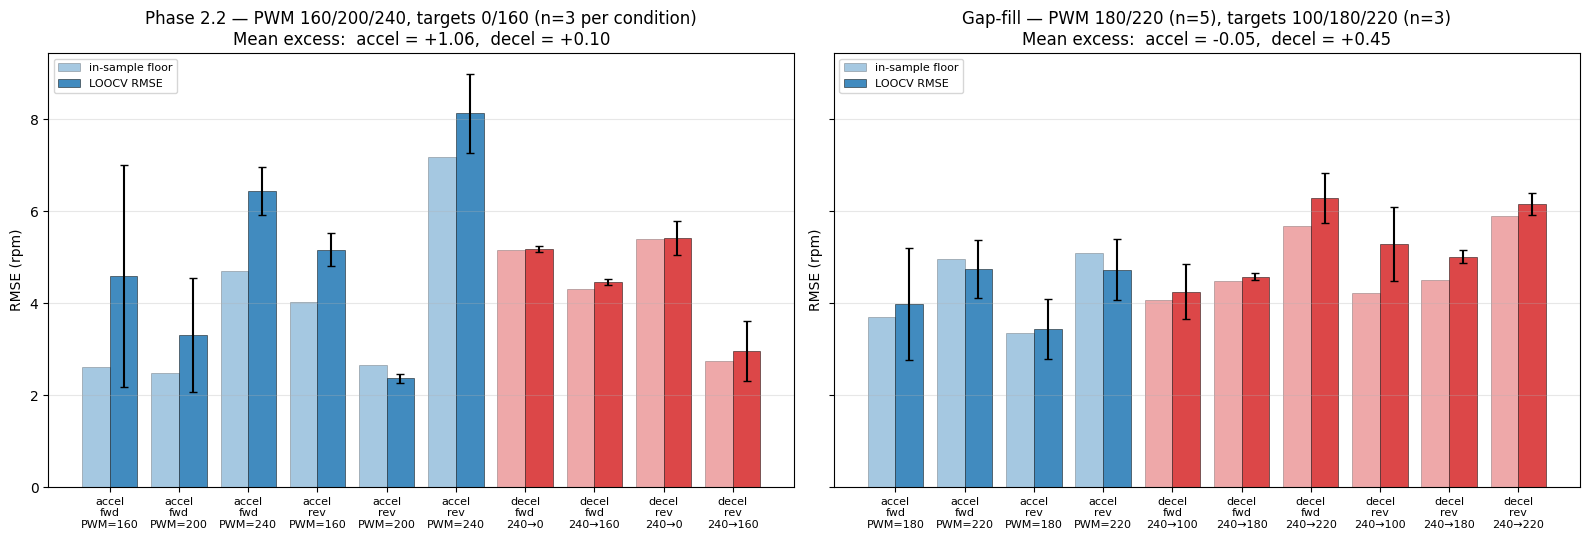


=== Combined LOOCV summary ===
           phase  type direction condition  n_trials  loocv_rmse_mean  in_sample_floor  excess
Phase 2.2 (orig) accel       fwd   PWM=160         3            4.589            2.615   1.974
Phase 2.2 (orig) accel       fwd   PWM=200         3            3.299            2.478   0.822
Phase 2.2 (orig) accel       fwd   PWM=240         3            6.440            4.689   1.751
Phase 2.2 (orig) accel       rev   PWM=160         3            5.161            4.029   1.132
Phase 2.2 (orig) accel       rev   PWM=200         3            2.363            2.658  -0.295
Phase 2.2 (orig) accel       rev   PWM=240         3            8.125            7.173   0.952
Phase 2.2 (orig) decel       fwd     240→0         3            5.171            5.160   0.012
Phase 2.2 (orig) decel       fwd   240→160         3            4.463            4.316   0.147
Phase 2.2 (orig) decel       rev     240→0         3            5.412            5.389   0.023
Phase 2.2 (orig) d

In [10]:
# Cell 9: combined LOOCV summary figure (Phase 2.2 + gap-fill)

# Load Phase 2.2 summary
p22_summary = pd.read_csv(DATA_PROCESSED / "phase21_loocv_summary.csv")

# Build gap-fill summary in the same schema
gf_accel_summary = accel_agg.copy()
gf_accel_summary['type'] = 'accel'
gf_accel_summary['condition'] = gf_accel_summary['pwm'].apply(lambda p: f"PWM={p}")
gf_accel_summary = gf_accel_summary.rename(columns={
    'rmse_rise_mean': 'loocv_rmse_mean',
    'rmse_rise_std':  'loocv_rmse_std',
    'rms_rise_floor': 'in_sample_floor',
    'n':              'n_trials',
})

gf_decel_summary = decel_agg.copy()
gf_decel_summary['type'] = 'decel'
gf_decel_summary['condition'] = gf_decel_summary.apply(
    lambda r: f"{int(r['start_pwm'])}→{int(r['target_pwm'])}", axis=1)
gf_decel_summary = gf_decel_summary.rename(columns={
    'rmse_fit_mean':   'loocv_rmse_mean',
    'rmse_fit_std':    'loocv_rmse_std',
    'rms_total_floor': 'in_sample_floor',
    'n':               'n_trials',
})

cols = ['type','direction','condition','n_trials','loocv_rmse_mean','loocv_rmse_std',
        'in_sample_floor','excess']
gf_combined = pd.concat([gf_accel_summary[cols], gf_decel_summary[cols]], ignore_index=True)

# Tag source and save
p22_summary['phase'] = 'Phase 2.2 (orig)'
gf_combined['phase'] = 'gap-fill (new)'
combined = pd.concat([p22_summary[cols + ['phase']], gf_combined[cols + ['phase']]],
                     ignore_index=True)
combined.to_csv(DATA_PROCESSED / "phase2gapfill_loocv_summary_combined.csv", index=False)

# Side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)

for ax, (phase_name, sub) in zip(axes, [
    (f'Phase 2.2 — PWM 160/200/240, targets 0/160 (n=3 per condition)', p22_summary),
    (f'Gap-fill — PWM 180/220 (n=5), targets 100/180/220 (n=3)',         gf_combined)
]):
    sub = sub.sort_values(['type','direction','condition']).reset_index(drop=True)
    labels = sub.apply(lambda r: f"{r['type']}\n{r['direction']}\n{r['condition']}", axis=1).values
    x = np.arange(len(sub))
    width = 0.4
    colors = ['C0' if t == 'accel' else 'C3' for t in sub['type']]
    ax.bar(x - width/2, sub['in_sample_floor'], width=width,
           color=colors, alpha=0.4, edgecolor='k', lw=0.4, label='in-sample floor')
    ax.bar(x + width/2, sub['loocv_rmse_mean'], width=width,
           color=colors, alpha=0.85, edgecolor='k', lw=0.4,
           yerr=sub['loocv_rmse_std'], capsize=3, label='LOOCV RMSE')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('RMSE (rpm)')
    accel_mean_excess = sub[sub.type=='accel'].excess.mean()
    decel_mean_excess = sub[sub.type=='decel'].excess.mean()
    ax.set_title(f"{phase_name}\nMean excess:  accel = {accel_mean_excess:+.2f},  "
                 f"decel = {decel_mean_excess:+.2f}")
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig(Path("../figures/19_loocv_phase22_vs_gapfill.png"), dpi=140)
plt.show()

print("\n=== Combined LOOCV summary ===")
print(combined[['phase','type','direction','condition','n_trials',
                'loocv_rmse_mean','in_sample_floor','excess']]
      .round(3).to_string(index=False))
print(f"\nSaved: phase2gapfill_loocv_summary_combined.csv (16 rows = 10 P22 + 6 gap-fill)")
